# CIFAR-10 Adversarial Attacks with PyTorch

This notebook applies the adversarial-learning progression to CIFAR-10 using a convolutional neural network. The original source code, comments, visualizations, and saved outputs are preserved.


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as dsets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torch.autograd import Variable

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history['accuracy'],label = 'train')
  ax[0].plot(history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)
  ax[1].plot(history['loss'],label = 'train')
  ax[1].plot(history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)

In [3]:
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = np.float32(tf.keras.utils.to_categorical(y_train, 10))
y_test_oh = np.float32(tf.keras.utils.to_categorical(y_test, 10))
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


# Adversarial examples for the CIFAR-10 Dataset


In [6]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
X_test, y_test = X_test[:1000], y_test[:1000]
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
# Convert images to channels-first format
X_train = np.moveaxis(X_train, -1, 1)
X_test = np.moveaxis(X_test, -1, 1)
X_train = np.float32(X_train)/255
X_test = np.float32(X_test)/255
y_train_oh = np.float32(tf.keras.utils.to_categorical(y_train, 10))
y_test_oh = np.float32(tf.keras.utils.to_categorical(y_test, 10))
y_train = np.squeeze(y_train)
y_test = np.squeeze(y_test)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')
X_train_t = torch.tensor(X_train).to(device)
y_train_oh_t = torch.tensor(y_train_oh).to(device)
X_test_t = torch.tensor(X_test).to(device)
y_test_oh_t = torch.tensor(y_test_oh).to(device)

X_train.shape=(50000, 32, 32, 3)
X_test.shape=(1000, 32, 32, 3)
X_train.shape=(50000, 3, 32, 32)
X_test.shape=(1000, 3, 32, 32)
y_train.shape=(50000,)
y_test.shape=(1000,)
y_train_oh.shape=(50000, 10)
y_test_oh.shape=(1000, 10)


convnn(
  (layers): ModuleList(
    (0): Conv2d(3, 50, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): Conv2d(50, 50, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(50, 100, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (6): ReLU()
    (7): Conv2d(100, 100, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(100, 200, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (11): ReLU()
    (12): Conv2d(200, 200, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=3200, out_features=100, bias=True)
    (17): Linear(in_features=100, out_features=10, bias=True)
  

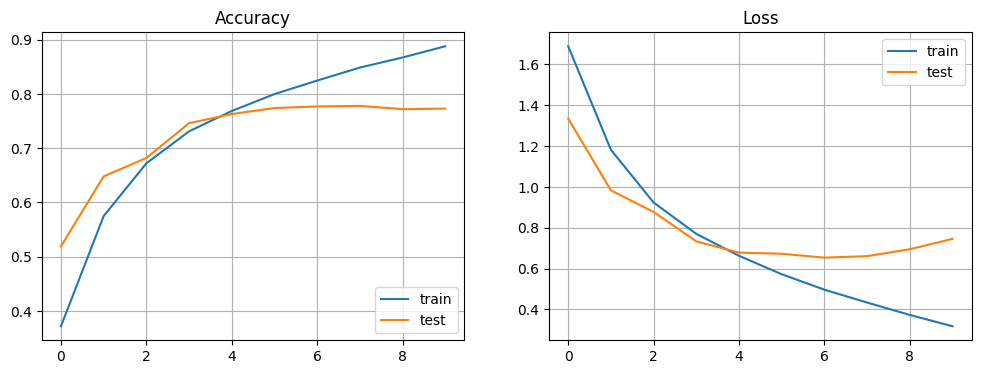

In [7]:
class convnn(nn.Module):
  def __init__(self,conv_layers,dense_units):
    super(convnn,self).__init__()
    self.layers = nn.ModuleList([])
    for i in range(1,len(conv_layers)):
      self.layers.append(nn.Conv2d(conv_layers[i-1], conv_layers[i], 3, padding='same'))
      self.layers.append(nn.ReLU())
      self.layers.append(nn.Conv2d(conv_layers[i], conv_layers[i], 3, padding='same'))
      self.layers.append(nn.ReLU())
      self.layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    self.layers.append(nn.Flatten())
    self.layers.append(nn.Linear(3200, dense_units))
    self.layers.append(nn.Linear(dense_units, 10))

  def forward(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

model = convnn([3,50,100,200],100).to(device)
print(model)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
batch_size = 100
size = X_train.shape[0]
start_train = time.time()
loss_list, acc_list  = [], []
loss_list_tst, acc_list_tst  = [], []
n_batches = X_train.shape[0]//batch_size
for epoch in range(1,num_epochs+1):
  pred_train = np.zeros(size,dtype= np.int32)
  batch_num = np.random.permutation(size)//batch_size
  sum_loss = 0
  for i in range(n_batches):
    pred = model(X_train_t[batch_num==i])
    pred_train[batch_num==i] = np.argmax(pred.cpu().detach().numpy(),axis=1)
    loss = loss_function(pred, y_train_oh_t[batch_num==i])
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    sum_loss+=loss.item()

  loss_list.append(batch_size*sum_loss/size)
  acc_list.append(accuracy_score(y_train,pred_train))
  with torch.no_grad():
    pred_test = model(X_test_t)
    loss_tst = loss_function(pred_test, y_test_oh_t).item()
  loss_list_tst.append(loss_tst)
  acc_list_tst.append(accuracy_score(y_test,np.argmax(pred_test.cpu().detach().numpy(),axis=1)))

  print(f'Epoch {epoch:2}/{num_epochs}  accuracy = {acc_list[-1]:.4f} loss = {loss_list[-1]:.6f} test accuracy = {acc_list_tst[-1]:.4f} test loss = {loss_list_tst[-1]:.6f} ')


end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
history = {'accuracy':acc_list, 'loss': loss_list, 'val_accuracy': acc_list_tst, 'val_loss': loss_list_tst}
plot_results(history)

Extract a list of images belonging to each class. *sample[i]* contains a list with the indices of all images of class *i*.


In [8]:
sample = [[] for i in range(10)]
for i,y in enumerate(y_test):
  sample[y].append(i)

Sample code to display original images, adversarial images and noise. Pytorch uses a channel-first format for images, while plt and tensorflow use a channels-last format. Thus we have to convert (3,32,32) arrays to (32,32,3) using the *moveaxis* function prior to display.


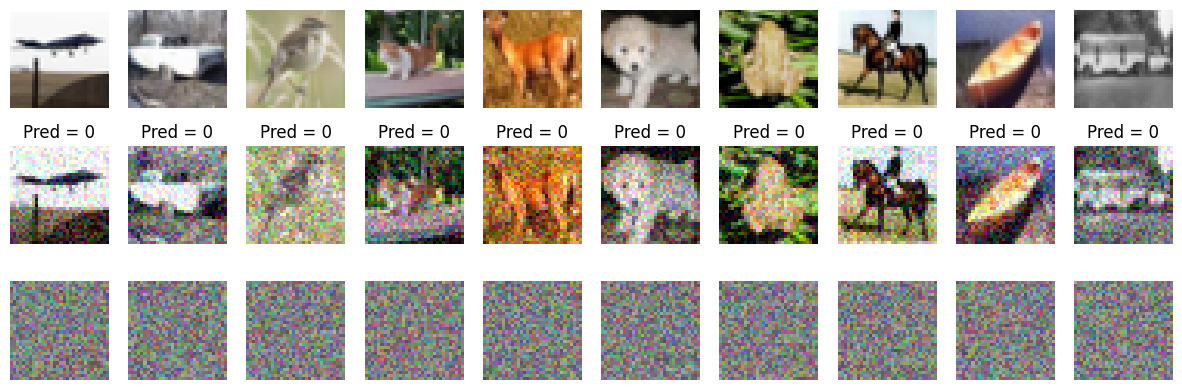

In [9]:
noise = np.random.uniform(-.2,.2,size = X_test.shape)
X_test_noisy = np.clip(X_test+noise,0,1)
pred_class = np.zeros(X_test.shape[0],dtype=int)

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(np.moveaxis(X_test[s], 0, -1))
  ax[0,i].axis("off")
  ax[1,i].imshow(np.moveaxis(X_test_noisy[s], 0, -1))
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(np.moveaxis(noise[s], 0, -1)+0.5)
  ax[2,i].axis("off")

# Generating adversarial examples adding random noise


sigma = 0.0050, acc = 0.7770
sigma = 0.0100, acc = 0.7640
sigma = 0.0150, acc = 0.7720
sigma = 0.0200, acc = 0.7690
sigma = 0.0250, acc = 0.7680
sigma = 0.0300, acc = 0.7610
sigma = 0.0350, acc = 0.7600
sigma = 0.0400, acc = 0.7640
sigma = 0.0450, acc = 0.7490
sigma = 0.0500, acc = 0.7470
sigma = 0.0550, acc = 0.7500
sigma = 0.0600, acc = 0.7470
sigma = 0.0650, acc = 0.7210
sigma = 0.0700, acc = 0.7180
sigma = 0.0750, acc = 0.7180
sigma = 0.0800, acc = 0.6940
sigma = 0.0850, acc = 0.6790
sigma = 0.0900, acc = 0.6590
sigma = 0.0950, acc = 0.6470
sigma = 0.1000, acc = 0.6190
sigma = 0.1050, acc = 0.6270
sigma = 0.1100, acc = 0.6170
sigma = 0.1150, acc = 0.6080
sigma = 0.1200, acc = 0.5880
sigma = 0.1250, acc = 0.5650
sigma = 0.1300, acc = 0.5630
sigma = 0.1350, acc = 0.5270
sigma = 0.1400, acc = 0.5320
sigma = 0.1450, acc = 0.5230
sigma = 0.1500, acc = 0.5000
sigma = 0.1550, acc = 0.4930
Confusion matrix
[[ 40   1  12   1  12   0  23   1  11   2]
 [  2  44   1   0   0   0  25   0   1  16

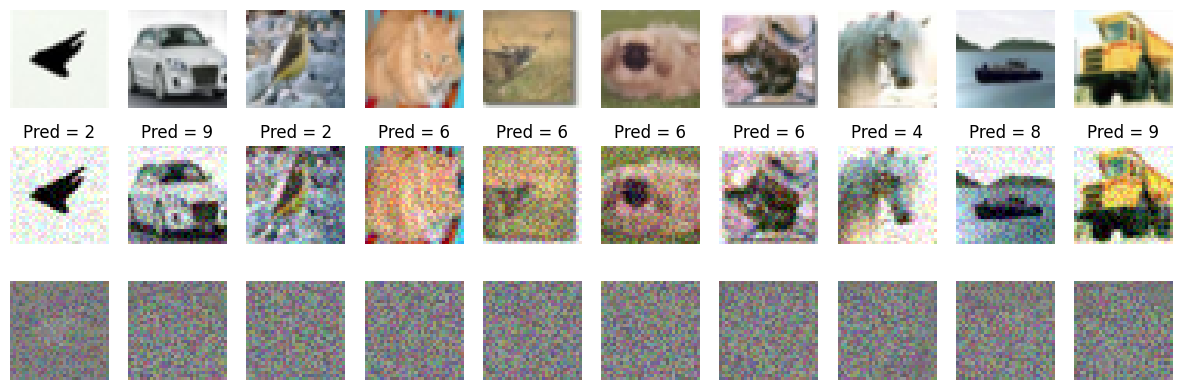

In [10]:
goal_acc = 0.5 # Exit loop when model accuracy on the adversarial data goes below this value
max_it = 200

for i in range(1,max_it):
  sigma = i/max_it # Sigma goes from 0.01 to 0.99 if max_it = 100
  noise = np.float32(np.random.uniform(-sigma, sigma, X_test.shape))
  X_test_noisy = np.clip(X_test+noise,0,1)
  pred = model(torch.tensor(X_test_noisy).to(device))
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test,pred_class)
  print(f'{sigma =:7.4f}, {acc =:7.4f}')
  if acc < goal_acc:
     break

print('Confusion matrix')
print(confusion_matrix(y_test,pred_class))

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_noisy - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(np.moveaxis(X_test[s], 0, -1))
  ax[0,i].axis("off")
  ax[1,i].imshow(np.moveaxis(X_test_noisy[s], 0, -1))
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(np.moveaxis(noise[s], 0, -1)+0.5)
  ax[2,i].axis("off")

# Generating adversarial examples using FGSM

Now we will apply the Fast Gradient Sign Method (FGSM) to generate adversarial examples for the CIFAR-10 dataset.


sigma = 0.0050, acc = 0.3630
sigma = 0.0100, acc = 0.1800
sigma = 0.0150, acc = 0.1140
sigma = 0.0200, acc = 0.0870
Confusion matrix
[[16 10 28  2  7  3  3  4 21  9]
 [ 9  9  2  1  0  0  8  0  8 52]
 [15  1 13  5 16 20 23  3  2  2]
 [ 6  0 17  0 12 30 29  6  0  3]
 [ 4  0 29  7  2  8 20 19  0  1]
 [ 0  1 23 31  5  0 13 12  0  1]
 [ 4  0 60 17 10  6 12  2  0  1]
 [ 5  3  8  7 27 36  6  6  0  4]
 [56 14  8  2  3  0  4  1 10  8]
 [19 45  4  2  1  1  6  3  9 19]]
Mean absolute noise =  0.0198
Max absolute noise =  0.0200


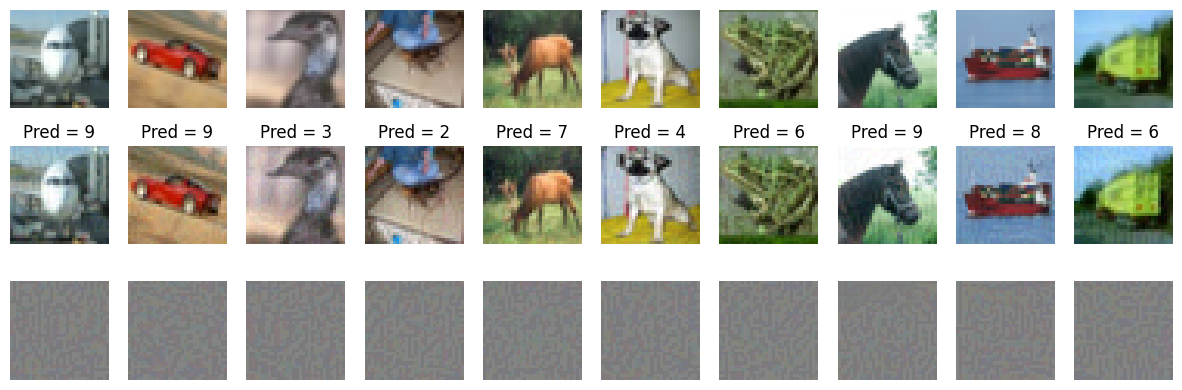

In [11]:
# FGSM non-targeted attack
X_test_gr = torch.tensor(X_test).to(device).requires_grad_(True)
pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_t)
loss.backward()
grad_sign = torch.sign(X_test_gr.grad).cpu().detach().numpy()

goal_acc = 0.1
max_it = 200

for i in range(1,max_it):
  sigma = i/max_it
  noise = sigma*grad_sign
  X_test_noisy = np.clip(X_test+noise,0,1)
  pred = model(torch.tensor(X_test_noisy).to(device))
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test,pred_class)
  print(f'{sigma =:7.4f}, {acc =:7.4f}')
  if acc < goal_acc:
     break

print('Confusion matrix')
print(confusion_matrix(y_test,pred_class))

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_noisy - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(np.moveaxis(X_test[s], 0, -1))
  ax[0,i].axis("off")
  ax[1,i].imshow(np.moveaxis(X_test_noisy[s], 0, -1))
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(np.moveaxis(noise[s], 0, -1)+0.5)
  ax[2,i].axis("off")

### FGSM with targeted attacks


sigma = 0.0100, acc = 0.3960
sigma = 0.0200, acc = 0.4560
sigma = 0.0300, acc = 0.4270
sigma = 0.0400, acc = 0.3650
sigma = 0.0500, acc = 0.2910
sigma = 0.0600, acc = 0.2290
sigma = 0.0700, acc = 0.1770
sigma = 0.0800, acc = 0.1340
sigma = 0.0900, acc = 0.0970
sigma = 0.1000, acc = 0.0660
sigma = 0.1100, acc = 0.0420
sigma = 0.1200, acc = 0.0320
sigma = 0.1300, acc = 0.0240
sigma = 0.1400, acc = 0.0170
sigma = 0.1500, acc = 0.0090
sigma = 0.1600, acc = 0.0070
sigma = 0.1700, acc = 0.0050
sigma = 0.1800, acc = 0.0030
sigma = 0.1900, acc = 0.0010
sigma = 0.2000, acc = 0.0000
sigma = 0.2100, acc = 0.0000
sigma = 0.2200, acc = 0.0000
sigma = 0.2300, acc = 0.0000
sigma = 0.2400, acc = 0.0000
sigma = 0.2500, acc = 0.0000
sigma = 0.2600, acc = 0.0000
sigma = 0.2700, acc = 0.0000
sigma = 0.2800, acc = 0.0000
sigma = 0.2900, acc = 0.0000
sigma = 0.3000, acc = 0.0000
sigma = 0.3100, acc = 0.0000
sigma = 0.3200, acc = 0.0000
sigma = 0.3300, acc = 0.0000
sigma = 0.3400, acc = 0.0000
sigma = 0.3500

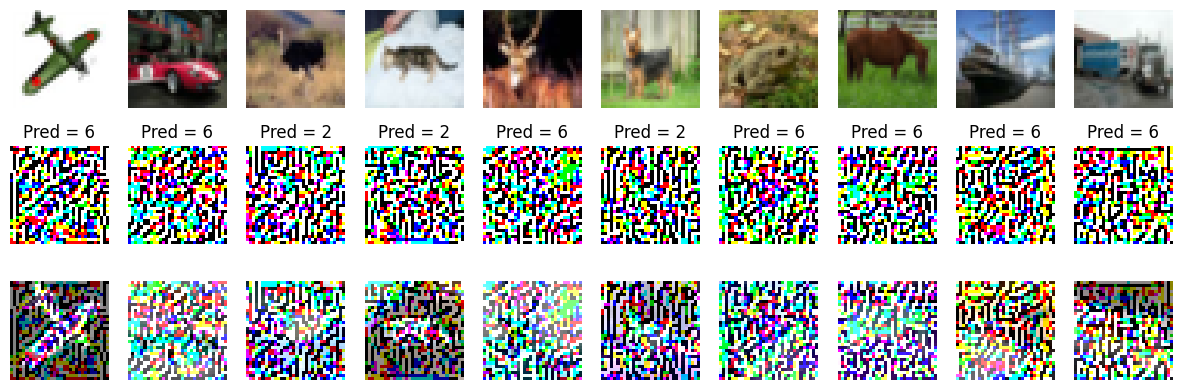

In [12]:

X_test_gr = torch.tensor(X_test).to(device).requires_grad_(True)
target_class = 5
goal_acc = 0.9

y_test_adv = np.zeros_like(y_test)
y_test_adv[:] = target_class
y_test_oh_adv = np.zeros_like(y_test_oh)
y_test_oh_adv[:,target_class] = 1

y_test_oh_adv_t = torch.tensor(y_test_oh_adv).to(device)

pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_adv_t)
loss.backward()
grad_sign = torch.sign(X_test_gr.grad).cpu().detach().numpy()

for i in range(1,100):
  sigma = i/100
  noise = -sigma*grad_sign
  X_test_noisy = np.clip(X_test+noise,0,1)
  pred = model(torch.tensor(X_test_noisy).to(device).detach())
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test_adv,pred_class)
  print(f'{sigma =:7.4f}, {acc =:7.4f}')
  if acc>goal_acc:
    break

print('Confusion matrix')
print(confusion_matrix(y_test,pred_class))

noise = X_test_noisy - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_noisy - X_test

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(np.moveaxis(X_test[s], 0, -1))
  ax[0,i].axis("off")
  ax[1,i].imshow(np.moveaxis(X_test_noisy[s], 0, -1))
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(np.moveaxis(noise[s], 0, -1)+0.5)
  ax[2,i].axis("off")

# Generating adversarial examples using Basic Iterative Method


i =  0, acc = 0.7730
i =  1, acc = 0.1800
i =  2, acc = 0.0250
Confusion matrix
[[ 6 12 29  1  8  4  4  6 24  9]
 [ 9  5  2  1  0  1  8  0  9 54]
 [23  1  1  4 14 23 25  5  3  1]
 [ 7  0 16  0  9 31 29  8  0  3]
 [ 4  0 28  5  0 10 22 19  1  1]
 [ 2  0 22 31  7  0 11 12  0  1]
 [ 4  0 64 17 12  8  3  3  0  1]
 [ 6  4  9 10 25 35  6  3  0  4]
 [61 17  9  2  2  0  4  2  0  9]
 [21 55  5  2  2  1  5  2  9  7]]
Mean absolute noise =  0.0123
Max absolute noise =  0.0200


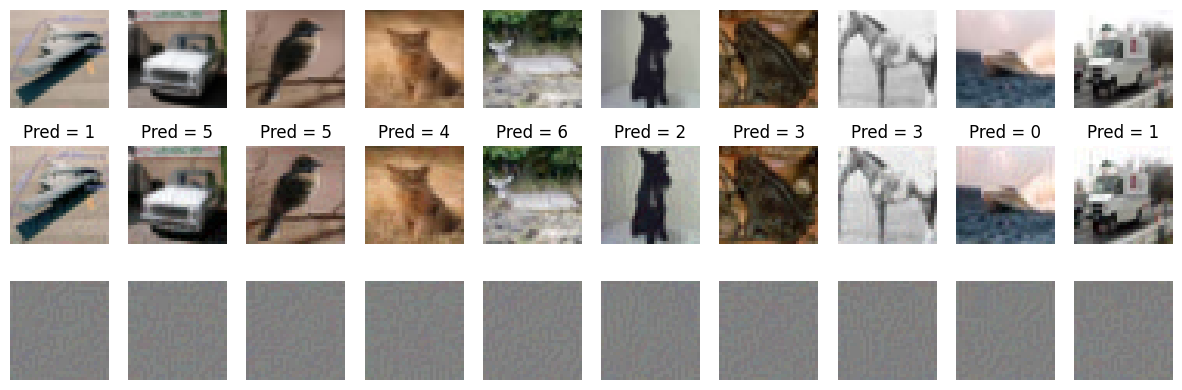

In [13]:
goal_acc = 0.1
max_it = 200

X_test_adv = torch.tensor(X_test).to(device).requires_grad_(True)
target_class = 0

y_test_adv_orig = np.copy(y_test)

sigma = 0.01
for i in range(max_it):
  pred = model(X_test_adv)
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test_adv_orig,pred_class)
  print(f'{i =:3}, {acc =:7.4f}')
  if acc < goal_acc:
     break
  loss = loss_function(pred, y_test_oh_t)
  loss.backward()
  grad_sign = torch.sign(X_test_adv.grad)
  noise = sigma*grad_sign
  X_test_adv.data = torch.clip(X_test_adv.data+noise,0,1)
  X_test_adv.grad.zero_()

print('Confusion matrix')
print(confusion_matrix(y_test_adv_orig,pred_class))

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_adv.data.cpu().detach().numpy() - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(np.moveaxis(X_test[s], 0, -1))
  ax[0,i].axis("off")
  ax[1,i].imshow(np.moveaxis(X_test_adv.data.cpu().detach().numpy()[s], 0, -1))
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(np.moveaxis(noise[s], 0, -1)+0.5)
  ax[2,i].axis("off")

i =  0, acc = 0.0970
i =  1, acc = 0.2880
i =  2, acc = 0.5010
i =  3, acc = 0.6810
i =  4, acc = 0.7880
i =  5, acc = 0.8630
i =  6, acc = 0.9120
Confusion matrix
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [ 24   3  21  11   3 912   9   3   8   6]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]]
Mean absolute noise =  0.0150
Max absolute noise =  0.0300


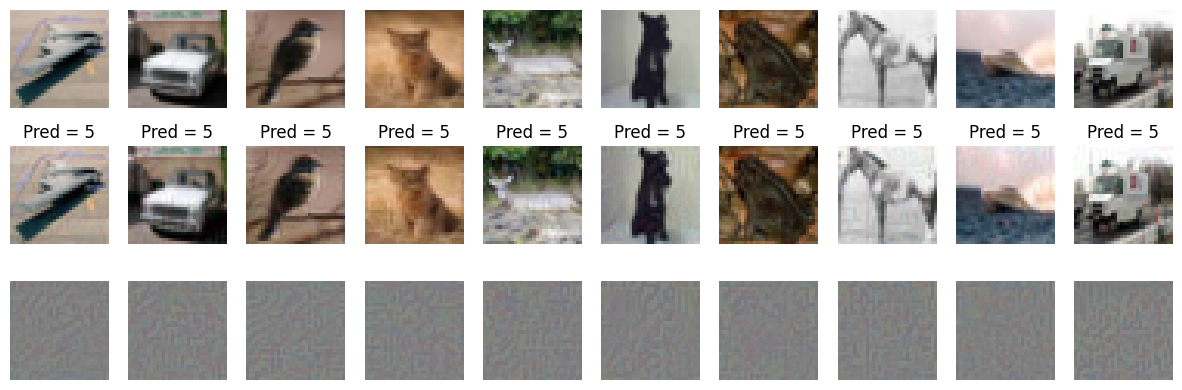

In [14]:
X_test_adv = torch.tensor(X_test).to(device).requires_grad_(True)
target_class = 5
goal_acc = 0.9

y_test_adv = np.zeros_like(y_test) + target_class

y_test_oh_adv = np.zeros_like(y_test_oh)
y_test_oh_adv[:,target_class] = 1

y_test_oh_adv_t = torch.tensor(y_test_oh_adv).to(device)

sigma = 0.005
for i in range(max_it):
  pred = model(X_test_adv)
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test_adv,pred_class)
  print(f'{i =:3}, {acc =:7.4f}')
  if acc > goal_acc:
     break
  loss = loss_function(pred, y_test_oh_adv_t)
  loss.backward()
  grad_sign = torch.sign(X_test_adv.grad)
  noise = -sigma*grad_sign
  X_test_adv.data = torch.clip(X_test_adv.data+noise,0,1)
  X_test_adv.grad.zero_()


print('Confusion matrix')
print(confusion_matrix(y_test_adv,pred_class,labels=np.arange(10)))

noise = X_test_adv.data.cpu().detach().numpy() - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(np.moveaxis(X_test[s], 0, -1), vmin=0, vmax=1, cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(np.moveaxis(X_test_adv.data.cpu().detach().numpy()[s], 0, -1), vmin=0, vmax=1, cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(np.moveaxis(noise[s], 0, -1)+0.5,  vmin=-.5, vmax=.5, cmap = "gray")
  ax[2,i].axis("off")